In [1]:
!pip install folium


DEPRECATION: Loading egg at c:\users\lavan\anaconda3\lib\site-packages\mask_rcnn-2.1-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [2]:
!pip install geopy

DEPRECATION: Loading egg at c:\users\lavan\anaconda3\lib\site-packages\mask_rcnn-2.1-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [3]:

import glob
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from geopy.distance import geodesic
from sklearn.preprocessing import MinMaxScaler
from itertools import combinations

In [4]:

 

 
file_path = r"C:\Users\lavan\OneDrive\Desktop\scrapping\output\FitnessRawDate_justdial\Raw_consolidated_justdial.csv"

df = pd.read_csv(file_path, encoding="utf-8")
df["Medium"] = "JustDial"
print(f"Initial row count: {len(df)}\n")
print(f"Sample Data view",df.head(5))



Initial row count: 522

Sample Data view                             name  \
0         Go Activ International   
1  Emerge Private Fitness Studio   
2                4th Station Gym   
3  Emerge Premium Fitness Studio   
4     Iconic Fitness Koramangala   

                                           address       phone rating  \
0           R V Road Cross Basavanagudi, Bangalore  9980235474    4.8   
1        24th Cross Jayanagar 6th Block, Bangalore  9606166994    4.8   
2          2nd Block Basaveshwara Nagar, Bangalore  6366558724    4.5   
3  S Kariyappa Road Jayanagar 7th Block, Bangalore  9054821932    4.8   
4    Wipro Signal Koramangala 1st Block, Bangalore  8904249820    4.7   

   reviews category    Medium  
0    107.0     Gyms  JustDial  
1      1.0     Gyms  JustDial  
2    467.0     Gyms  JustDial  
3    119.0     Gyms  JustDial  
4    802.0     Gyms  JustDial  


In [5]:


# Clean address column
df["address"] = df["address"].astype(str).str.strip()

# Extract city
df["City"] = df["address"].str.split(",").str[-1].str.strip()

# Remove city part
df["temp_address"] = df["address"].str.rsplit(",", n=1).str[0].str.strip()

import re
import pandas as pd

def extract_pure_area(text):

    if pd.isna(text) or text == "Unknown":
        return "Unknown"

    text = str(text).strip()

    # Remove Bangalore
    text = re.sub(r",?\s*Bangalore.*", "", text, flags=re.IGNORECASE)

    # Remove pincode
    text = re.sub(r"\b\d{6}\b", "", text)

    # Remove prefixes like:
    # 19th Main Road
    # 24th Cross
    text = re.sub(
        r"\d+\s*(?:st|nd|rd|th)?\s*(Main Road|Road|Rd|Cross)\b",
        "",
        text,
        flags=re.IGNORECASE,
    )

    # Remove Sector/Block/Stage/Phase with numbers
    text = re.sub(
        r"(Sector|Block|Stage|Phase)\s*\d+",
        "",
        text,
        flags=re.IGNORECASE,
    )

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text.title()

In [6]:
print(df.head(5))

                            name  \
0         Go Activ International   
1  Emerge Private Fitness Studio   
2                4th Station Gym   
3  Emerge Premium Fitness Studio   
4     Iconic Fitness Koramangala   

                                           address       phone rating  \
0           R V Road Cross Basavanagudi, Bangalore  9980235474    4.8   
1        24th Cross Jayanagar 6th Block, Bangalore  9606166994    4.8   
2          2nd Block Basaveshwara Nagar, Bangalore  6366558724    4.5   
3  S Kariyappa Road Jayanagar 7th Block, Bangalore  9054821932    4.8   
4    Wipro Signal Koramangala 1st Block, Bangalore  8904249820    4.7   

   reviews category    Medium       City                          temp_address  
0    107.0     Gyms  JustDial  Bangalore           R V Road Cross Basavanagudi  
1      1.0     Gyms  JustDial  Bangalore        24th Cross Jayanagar 6th Block  
2    467.0     Gyms  JustDial  Bangalore          2nd Block Basaveshwara Nagar  
3    119.0     Gyms 

In [7]:
df["area"]=df["temp_address"]

In [8]:
df.drop(columns="temp_address", inplace=True)

In [9]:
df["area"] = df["area"].str.replace(
    r"\b\d{6}\b",
    "",
    regex=True
).str.strip()

In [10]:
df["City"] = df["City"].str.replace(
    r"\b\d{6}\b",
    "",
    regex=True
).str.strip()

In [11]:
df["area"] = df["area"].str.replace(
    r"\b\d+\w*\s*[A-Z]?\s*(Main Road|Main|Road|Rd|Cross|Block)\b",
    "",
    regex=True,
).str.replace(r"\s+", " ", regex=True).str.strip()

In [12]:
df.head(5)

,name,address,phone,rating,reviews,category,Medium,City,area
0,Go Activ International,"R V Road Cross Basavanagudi, Bangalore",9980235474,4.8,107.0,Gyms,JustDial,Bangalore,R V Road Cross Basavanagudi
1,Emerge Private Fitness Studio,"24th Cross Jayanagar 6th Block, Bangalore",9606166994,4.8,1.0,Gyms,JustDial,Bangalore,Jayanagar
2,4th Station Gym,"2nd Block Basaveshwara Nagar, Bangalore",6366558724,4.5,467.0,Gyms,JustDial,Bangalore,Basaveshwara Nagar
3,Emerge Premium Fitness Studio,"S Kariyappa Road Jayanagar 7th Block, Bangalore",9054821932,4.8,119.0,Gyms,JustDial,Bangalore,S Kariyappa Road Jayanagar
4,Iconic Fitness Koramangala,"Wipro Signal Koramangala 1st Block, Bangalore",8904249820,4.7,802.0,Gyms,JustDial,Bangalore,Wipro Signal Koramangala


In [13]:
# =========================================================================
# RULE 1: DUPLICATE RECORDS
# =========================================================================
print("Applying Rule 1: Handling Duplicates...")
initial_count = len(df)

# A. Remove exact 100% duplicate rows across the whole dataset
df.drop_duplicates(inplace=True)
print(f"-> Removed {initial_count - len(df)} exact row duplicates.")

# B. Flag near-duplicates sharing same business Name + Area / Locality
# keep=False flags ALL instances that match the criteria so you can easily review them
df["is_near_duplicate"] = df.duplicated(
    subset=["name", "area"], keep=False
)
print(
    f"-> Flagged {df['is_near_duplicate'].sum()} records as potential near-duplicates.\n"
)

Applying Rule 1: Handling Duplicates...
-> Removed 0 exact row duplicates.
-> Flagged 99 records as potential near-duplicates.



In [14]:
# =========================================================================
# RULE 2: MISSING PHONE / EMAIL
# =========================================================================
print("Applying Rule 2: Handling Missing Contacts...")

# Convert Justdial's 'Show Number' placeholder or empty slots into clean NaNs
df["phone"] = df["phone"].replace(
    ["Show Number", "show number", "Show  Number", "", " "], np.nan
)

# Flag missing contacts into a boolean tracking column
df["missing_contact"] = df["phone"].isna()
print(
    f"-> Identified {df['missing_contact'].sum()} listings missing a phone number.\n"
)

Applying Rule 2: Handling Missing Contacts...
-> Identified 417 listings missing a phone number.



In [15]:
# =========================================================================
# RULE 3: INCONSISTENT RATINGS
# =========================================================================
print("Applying Rule 3: Standardizing Ratings & Removing Null Activity...")

# Enforce clean numerical evaluation on a standard 0 to 5 scale
df["rating"] = pd.to_numeric(df["rating"], errors="coerce").fillna(0).clip(0, 5)
df["reviews"] = (
    pd.to_numeric(df["reviews"], errors="coerce").fillna(0).astype(int)
)

# Drop entries where BOTH rating and review count are exactly 0
before_drop = len(df)
df = df[~((df["rating"] == 0) & (df["reviews"] == 0))]
print(
    f"-> Dropped {before_drop - len(df)} ghost entries with 0 rating AND 0 reviews.\n"
)


Applying Rule 3: Standardizing Ratings & Removing Null Activity...
-> Dropped 27 ghost entries with 0 rating AND 0 reviews.



In [16]:
# =========================================================================
# RULE 4: INCONSISTENT AREA NAMES (LOCALITY STANDARDIZATION)
# =========================================================================
print("Applying Rule 4: Standardizing Locality Names...")

# Dictionary mapping framework to correct common acronyms/short forms
area_mapping = {
    "Hsr": "HSR Layout",
    "Btm": "BTM Layout",
    "Jp": "JP Nagar",
    "Rt": "RT Nagar",
    "Indira": "Indiranagar",
    "Basavanagudi": "Basavanagudi",
    "Jayanagar": "Jayanagar",
}

# Standardize values across the cleaned column
df["area"] = df["area"].replace(area_mapping)
print(f"-> Applied locality normalization dictionary mapping.\n")


Applying Rule 4: Standardizing Locality Names...
-> Applied locality normalization dictionary mapping.



In [17]:
# =========================================================================
# RULE 5: CATEGORY INCONSISTENCY
# =========================================================================
print("Applying Rule 5: Normalizing Categories...")

# Mapping dirty web-scraped variants to standardized clean text names
category_mapping = {
    "Pilates-Studio": "Pilates Studio",
    "Gyms": "Gym",
    "Dance-Zumba-Studio": "Dance & Zumba Studio",
    "Fitness-Studio": "Fitness Studio",
    "Karate-Dojo": "Karate Dojo",
    "Yoga-Centres": "Yoga Centre",
}
df["category"] = df["category"].replace(category_mapping)
print(f"-> Standardized listings into organized category segments.\n")


Applying Rule 5: Normalizing Categories...
-> Standardized listings into organized category segments.



In [18]:
df["category"].values

array(['Gym', 'Gym', 'Gym', 'Gym', 'Gym', 'Gym', 'Gym', 'Gym', 'Gym',
       'Gym', 'Gym', 'Gym', 'Gym', 'Gym', 'Gym', 'Gym', 'Gym', 'Gym',
       'Gym', 'Gym', 'Gym', 'Gym', 'Gym', 'Gym', 'Gym', 'Gym', 'Gym',
       'Gym', 'Gym', 'Gym', 'Fitness Studio', 'Fitness Studio',
       'Fitness Studio', 'Fitness Studio', 'Fitness Studio',
       'Fitness Studio', 'Fitness Studio', 'Fitness Studio',
       'Fitness Studio', 'Fitness Studio', 'Fitness Studio',
       'Fitness Studio', 'Fitness Studio', 'Fitness Studio',
       'Fitness Studio', 'Fitness Studio', 'Fitness Studio',
       'Fitness Studio', 'Fitness Studio', 'Fitness Studio',
       'Fitness Studio', 'Fitness Studio', 'Fitness Studio',
       'Fitness Studio', 'Fitness Studio', 'Fitness Studio',
       'Fitness Studio', 'Fitness Studio', 'Fitness Studio',
       'Fitness Studio', 'Fitness Studio', 'Fitness Studio',
       'Fitness Studio', 'Fitness Studio', 'Fitness Studio',
       'Fitness Studio', 'Fitness Studio', 'Fitness Stu

In [19]:
# =========================================================================
# RULE 6: INVALID PHONE NUMBERS
# =========================================================================
print("Applying Rule 6: Validating Indian Phone Formats...")


def validate_indian_phone(phone_val):
    if pd.isna(phone_val):
        return (
            True  # Missing is already tracked separately in 'missing_contact'
        )

    # Strip away country codes (+91), spaces, or dashes, leaving only numbers
    digits = re.sub(r"\D", "", str(phone_val))
    if digits.startswith("91") and len(digits) > 10:
        digits = digits[2:]

    # Check for valid 10-digit mobile or 11/12 digit landline beginning with 0
    if len(digits) == 10:
        return True
    elif len(digits) in [11, 12] and digits.startswith("0"):
        return True
    return False


# Flag entries that contain numbers, but do not match real telecom length criteria
df["invalid_phone"] = df["phone"].apply(
    lambda x: not validate_indian_phone(x) if pd.notna(x) else False
)
print(
    f"-> Flagged {df['invalid_phone'].sum()} entries with malformed/invalid phone structures.\n"
)


Applying Rule 6: Validating Indian Phone Formats...
-> Flagged 6 entries with malformed/invalid phone structures.



# Since My data doesnt have price column so written only pseudocode for now 

# =========================================================================
# RULE 7: PRICE RANGE NORMALISATION
# =========================================================================
print("Applying Rule 7: Stratifying Monthly Price Ranges...")

# Dynamic safe-check: if a monthly price column isn't tracked yet, initialize an empty one
if "price_per_month" not in df.columns:
    df["price_per_month"] = np.nan


def classify_price_tier(price):
    if pd.isna(price) or price <= 0:
        return "Unspecified"
    if price < 2000:
        return "Budget"
    elif 2000 <= price <= 5000:
        return "Mid"
    else:
        return "Premium"


df["Price_Segment"] = df["price_per_month"].apply(classify_price_tier)
print(f"-> Classified fields into Budget, Mid, and Premium segments.\n")


# =========================================================================
# SAVE COMPLETED OUTPUT
# =========================================================================
output_path = r"C:\Users\lavan\OneDrive\Desktop\scrapping\output\FitnessRawDate_justdial\fully_cleaned_justdial.csv"
df.to_csv(output_path, index=False, encoding="utf-8")

print("=" * 60)
print("ALL CLEANING RULES APPIED SUCCESSFULLY!")
print(f"Final safe row count: {len(df)}")
print(f"Cleaned file exported to: {output_path}")
print("=" * 60)

In [20]:
output_path = r"C:\Users\lavan\OneDrive\Desktop\scrapping\output\FitnessRawDate_justdial\fully_cleaned_justdial.csv"
df.to_csv(output_path, index=False, encoding="utf-8")

print("=" * 60)
print("ALL CLEANING RULES APPIED SUCCESSFULLY!")
print(f"Final safe row count: {len(df)}")
print(f"Cleaned file exported to: {output_path}")
print("=" * 60)

ALL CLEANING RULES APPIED SUCCESSFULLY!
Final safe row count: 495
Cleaned file exported to: C:\Users\lavan\OneDrive\Desktop\scrapping\output\FitnessRawDate_justdial\fully_cleaned_justdial.csv


# Analysis Requirements

In [21]:
locality_counts = (
    df.groupby("area")
    .size()
    .reset_index(name="centre_count")
    .sort_values(by="centre_count", ascending=False)
)

print(locality_counts.head())

                                area  centre_count
174                        Jayanagar            11
59                         Bangalore             8
200                      Koramangala             6
383  Whitefield Main Road Whitefield             5
68                Basaveshwara Nagar             4


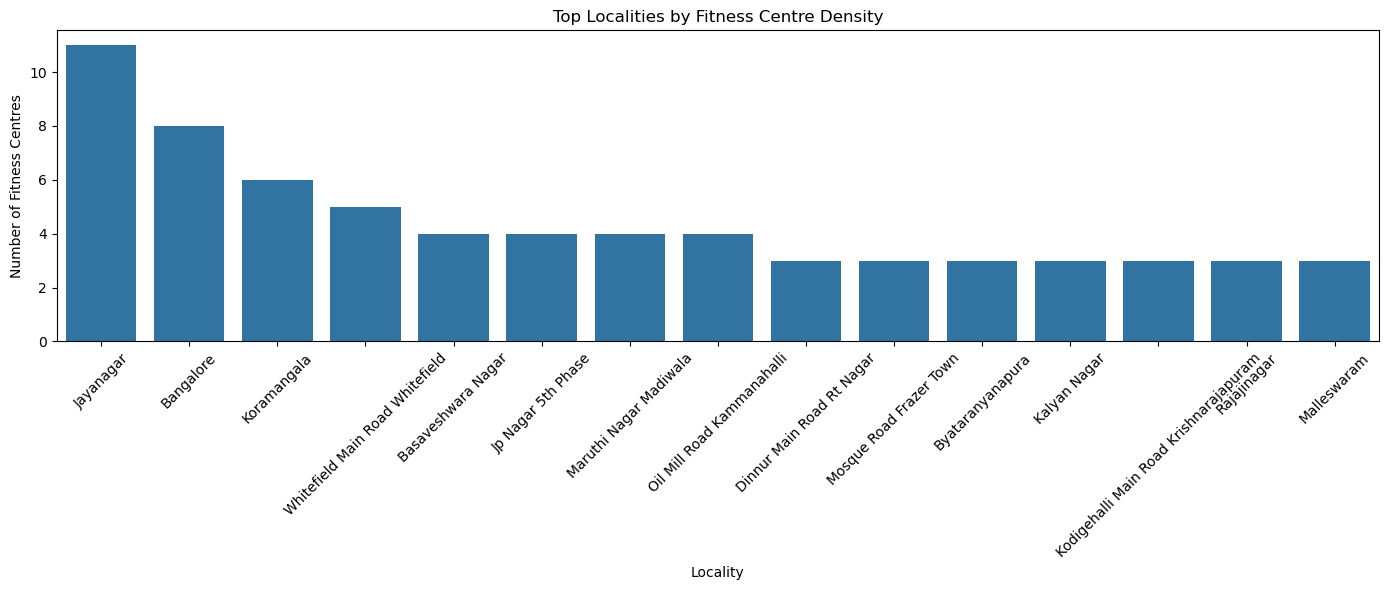

In [22]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=locality_counts.head(15),
    x="area",
    y="centre_count"
)

plt.xticks(rotation=45)
plt.title("Top Localities by Fitness Centre Density")
plt.xlabel("Locality")
plt.ylabel("Number of Fitness Centres")
plt.tight_layout()
plt.show()

In [23]:
top5_localities = locality_counts.head(5)

print(top5_localities)

                                area  centre_count
174                        Jayanagar            11
59                         Bangalore             8
200                      Koramangala             6
383  Whitefield Main Road Whitefield             5
68                Basaveshwara Nagar             4


In [24]:
print(df.columns)

Index(['name', 'address', 'phone', 'rating', 'reviews', 'category', 'Medium',
       'City', 'area', 'is_near_duplicate', 'missing_contact',
       'invalid_phone'],
      dtype='object')


In [25]:
print(df.columns)

Index(['name', 'address', 'phone', 'rating', 'reviews', 'category', 'Medium',
       'City', 'area', 'is_near_duplicate', 'missing_contact',
       'invalid_phone'],
      dtype='object')


In [26]:
# 4.1.4 Opportunity Gap Analysis

# Assumption:

# High reviews = high demand

# Low centres = low supply


opportunity_df = (
    df.groupby("area")
    .agg(
        total_centres=("name", "count"),
        total_reviews=("reviews", "sum")
    )
    .reset_index()
)

opportunity_df["demand_supply_ratio"] = (
    opportunity_df["total_reviews"] /
    opportunity_df["total_centres"]
)

opportunity_df = opportunity_df.sort_values(
    by="demand_supply_ratio",
    ascending=False
)

print(opportunity_df.head(10))




                                       area  total_centres  total_reviews  \
254  Next to G T Residential Layout Laggere              1            962   
296                    Road C V Raman Nagar              1            922   
290           Residency Road Residency Road              1            910   
29               8th Mile Peenya Nagasandra              1            892   
127                               Girinagar              1            889   
132             Green Glen Layout Bellandur              1            884   
122     Gandhi Bazar Main Road Basavanagudi              2           1766   
222   Marathahalli Sarjapur Road HSR Layout              1            871   
367                    Venkateshwara Layout              1            841   
264  Opposite BMTC Bus Stand Chandra Layout              1            832   

     demand_supply_ratio  
254                962.0  
296                922.0  
290                910.0  
29                 892.0  
127              

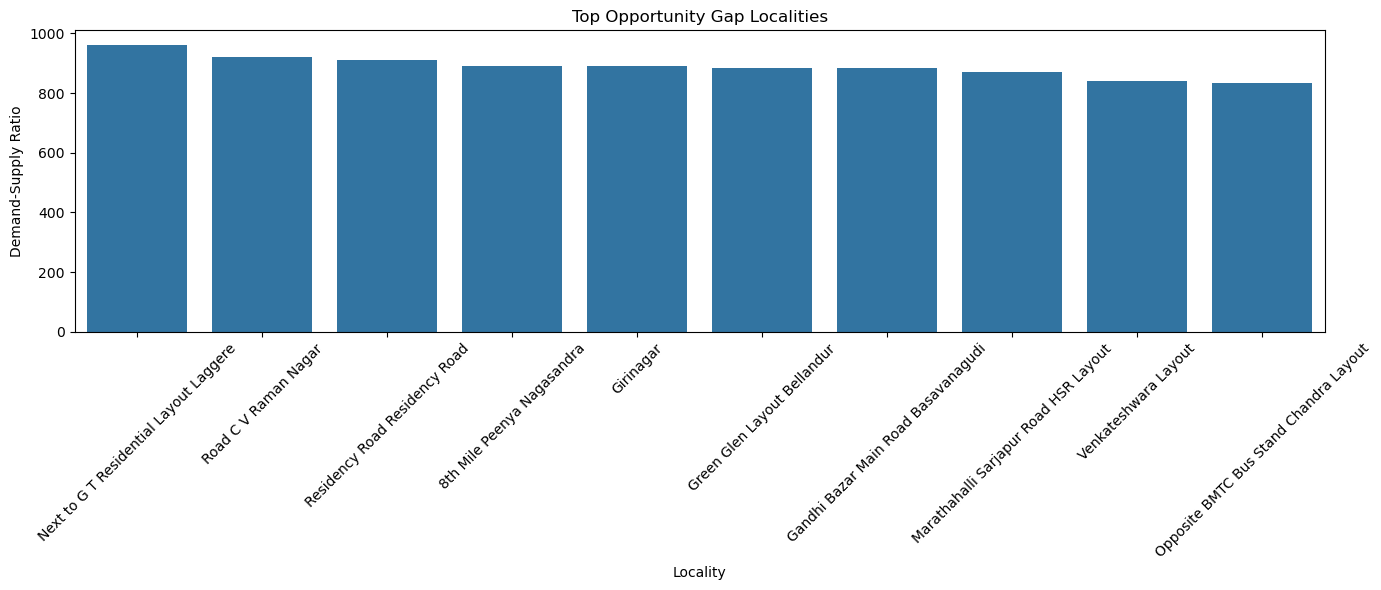

In [27]:
# Opportunity Gap Chart


plt.figure(figsize=(14,6))

sns.barplot(
    data=opportunity_df.head(10),
    x="area",
    y="demand_supply_ratio"
)

plt.xticks(rotation=45)
plt.title("Top Opportunity Gap Localities")
plt.xlabel("Locality")
plt.ylabel("Demand-Supply Ratio")
plt.tight_layout()
plt.show()




               category  count
7        Pilates Studio     89
9           Yoga Centre     89
3        Fitness Studio     71
0       Calisthenic-Gym     58
8     Taekwondo-Academy     44
6     Kickboxing-Studio     43
2  Dance & Zumba Studio     35
4                   Gym     30
5           Karate Dojo     29
1          CrossFit-Box      7


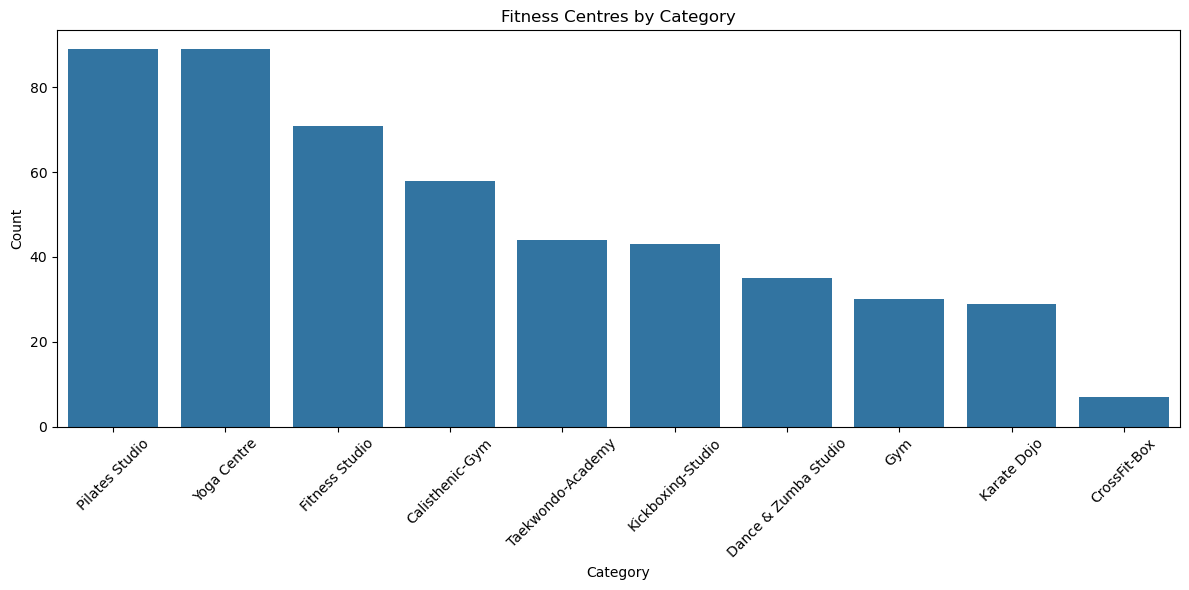

In [28]:
# =============================================

# 4.3 CATEGORY-WISE ANALYSIS

# =============================================

# 4.3.1 Category with Most Centres


category_counts = (
    df.groupby("category")
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)

print(category_counts)
 

# Category Count Chart


plt.figure(figsize=(12,6))

sns.barplot(
    data=category_counts,
    x="category",
    y="count"
)

plt.xticks(rotation=45)
plt.title("Fitness Centres by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

               category    rating
8     Taekwondo-Academy  4.790909
9           Yoga Centre  4.773034
1          CrossFit-Box  4.771429
0       Calisthenic-Gym  4.656897
4                   Gym  4.640000
6     Kickboxing-Studio  4.625581
3        Fitness Studio  4.576056
7        Pilates Studio  4.571910
2  Dance & Zumba Studio  4.428571
5           Karate Dojo  4.413793


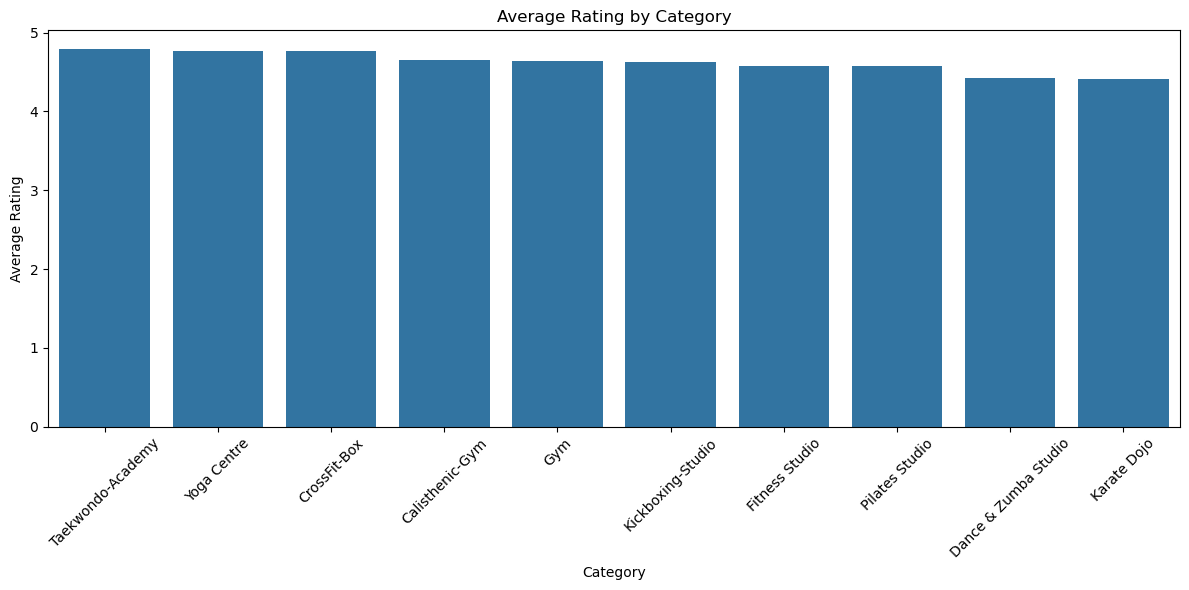

In [29]:
# 4.3.2 Highest Average Rating by Category

 
category_rating = (
    df.groupby("category")
    ["rating"]
    .mean()
    .reset_index()
    .sort_values(by="rating", ascending=False)
)

print(category_rating)
 

# Rating by Category Chart
 
plt.figure(figsize=(12,6))

sns.barplot(
    data=category_rating,
    x="category",
    y="rating"
)

plt.xticks(rotation=45)
plt.title("Average Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()

In [30]:
# 4.3.3 Underrepresented Categories
 
locality_population_proxy = (
    df.groupby("area")
    ["reviews"]
    .sum()
    .reset_index(name="population_proxy")
)

category_locality = (
    df.groupby(["area", "category"])
    .size()
    .reset_index(name="centre_count")
)

underrepresented = pd.merge(
    category_locality,
    locality_population_proxy,
    on="area"
)

underrepresented["gap_score"] = (
    underrepresented["population_proxy"] /
    underrepresented["centre_count"]
)

print(
    underrepresented.sort_values(
        by="gap_score",
        ascending=False
    ).head(10)
)
 


                                     area           category  centre_count  \
149   Gandhi Bazar Main Road Basavanagudi                Gym             1   
148   Gandhi Bazar Main Road Basavanagudi     Fitness Studio             1   
3    100 Feet Inner Ring Road Koramangala    Calisthenic-Gym             1   
4    100 Feet Inner Ring Road Koramangala  Kickboxing-Studio             1   
5    100 Feet Inner Ring Road Koramangala     Pilates Studio             1   
467              Wipro Signal Koramangala                Gym             1   
466              Wipro Signal Koramangala     Fitness Studio             1   
208                             Jayanagar                Gym             2   
209                             Jayanagar     Pilates Studio             2   
244                           Koramangala       CrossFit-Box             1   

     population_proxy  gap_score  
149              1766     1766.0  
148              1766     1766.0  
3                1752     1752.0  
4

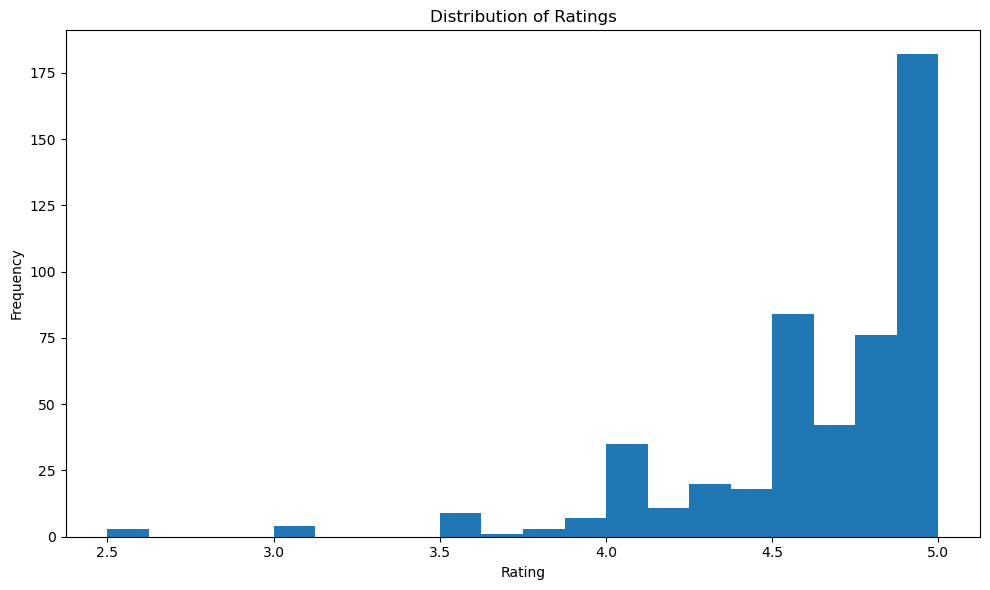

In [31]:
# =============================================

# 4.4 RATING & REVIEW ANALYSIS

# =============================================

# 4.4.1 Rating Distribution Histogram
 
plt.figure(figsize=(10,6))

plt.hist(df["rating"], bins=20)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
 

In [32]:
# 4.4.2 Top 10 Highest Rated Centres with 50+ Reviews
 
top_centres = df[
    (df["reviews"] >= 50)
]


top_centres = top_centres.sort_values(
    by=["rating", "reviews"],
    ascending=False
)

print(
    top_centres[
        [
            "name",
            "category",
            "area",
            "rating",
            "reviews"
        ]
    ].head(10)
)
 



                             name        category  \
297                  Fit City Gym  Pilates Studio   
434        Sri Sri School Of Yoga     Yoga Centre   
435         Paripurna Yoga Kendra     Yoga Centre   
436      Sai Power Yoga Institute     Yoga Centre   
438  Sri Sai Powar Yoga Institute     Yoga Centre   
439               Isha Hatha Yoga     Yoga Centre   
447   Aarogyadwar Holistic Center     Yoga Centre   
318         Siddhi Fitness Studio  Pilates Studio   
320                  Barbellhouse  Pilates Studio   
454    Kushiyogalaya Yoga Classes     Yoga Centre   

                                   area  rating  reviews  
297                Road C V Raman Nagar     5.0      922  
434             21st Km Kanakapura Road     5.0      811  
435                  Yelahanka New Town     5.0      720  
436      Bannerghatta Road Akshayanagar     5.0      587  
438           Road Devarachikkana Halli     5.0      568  
439                     An Gupta Layout     5.0      553  
447

          reviews    rating
reviews  1.000000  0.007077
rating   0.007077  1.000000


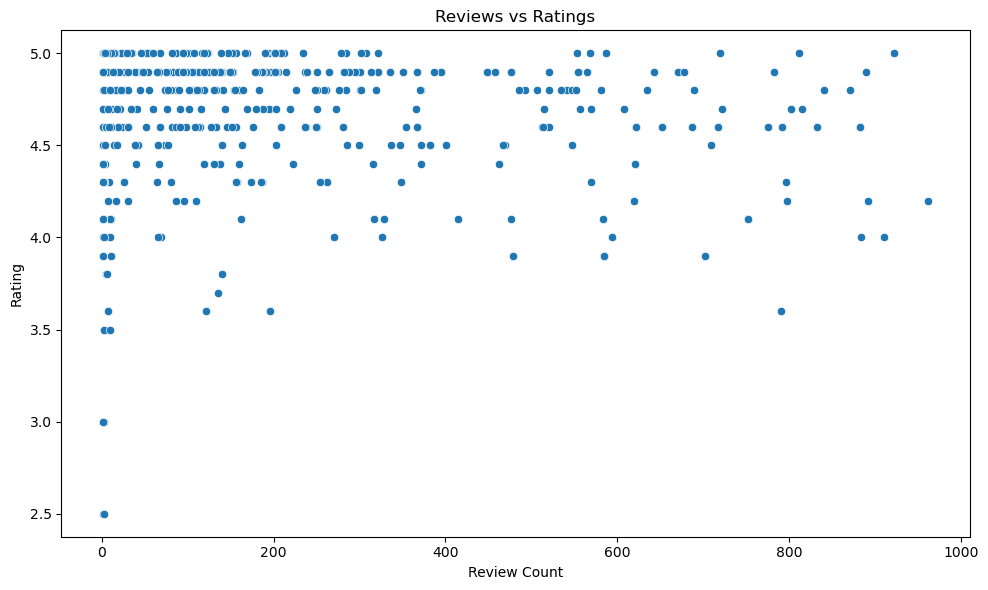

In [33]:
# 4.4.3 Correlation Between Reviews and Ratings

 
correlation = df[["reviews", "rating"]].corr()

print(correlation)
 
# Scatter Plot

 
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="reviews",
    y="rating"
)

plt.title("Reviews vs Ratings")
plt.xlabel("Review Count")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()
 



                                             area  rating
0                             #121 Sahakara Nagar     5.0
149           HSR Sector5/jakkasandra Koramangala     5.0
221     Marathahalli Outer Ring Road Marathahalli     5.0
216                  Main Road Kaggadasapura Road     5.0
214                  Magadi Main Road Anjananagar     5.0
203          Kothnur Main Road Jp Nagar 7th Phase     5.0
193     Kempegowda Layout Outer Ring Road Laggere     5.0
185  Kachohalli Main Road ISRO Layout Kumaraswamy     5.0
184                           KV Layout Jayanagar     5.0
176    Joyshree Sangha Kalitala Kolkata Bansdroni     5.0


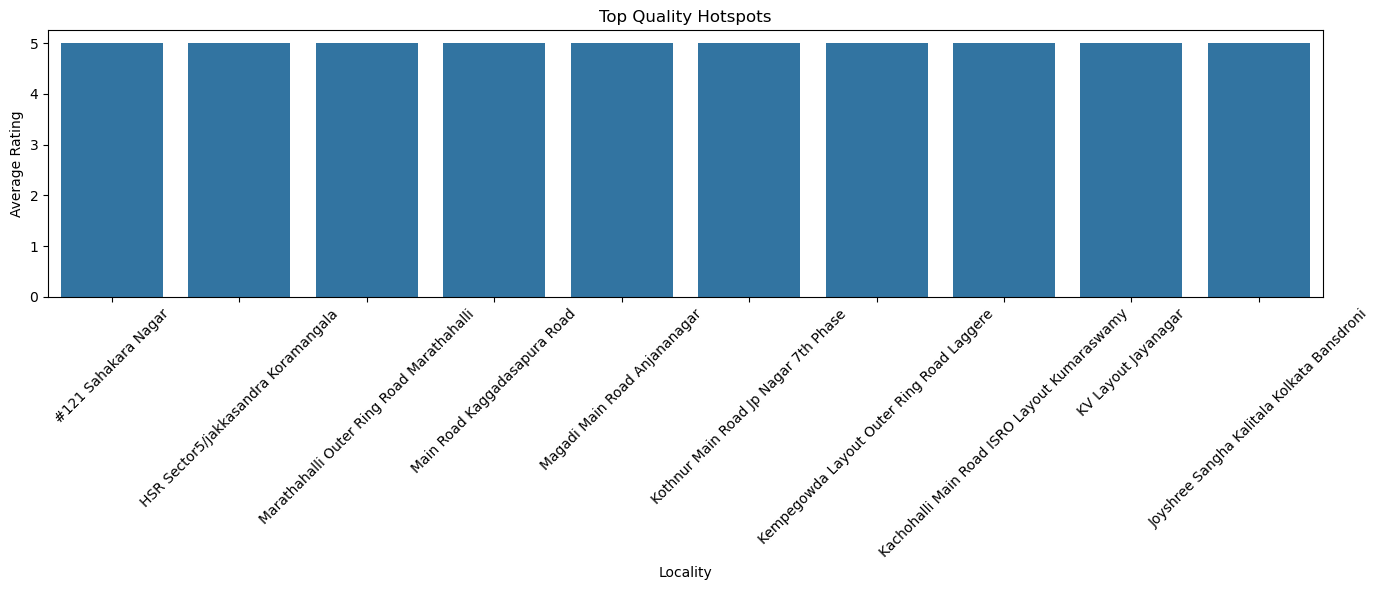

In [34]:
# 4.4.4 Quality Hotspots


quality_hotspots = (
    df.groupby("area")
    ["rating"]
    .mean()
    .reset_index()
    .sort_values(by="rating", ascending=False)
)

print(quality_hotspots.head(10))


# Quality Hotspot Chart

plt.figure(figsize=(14,6))

sns.barplot(
    data=quality_hotspots.head(10),
    x="area",
    y="rating"
)

plt.xticks(rotation=45)
plt.title("Top Quality Hotspots")
plt.xlabel("Locality")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()




                                        area  contact_completeness
122      Gandhi Bazar Main Road Basavanagudi                   1.0
190      Kammanahalli Main Road Kammanahalli                   1.0
277              R V Road Cross Basavanagudi                   1.0
35        Ambedkar Nagar Hill Top Whitefield                   1.0
232    Modi Hospital Road Basaveshwara Nagar                   1.0
135                     Gulmohor Road Savedi                   1.0
235  Muneshwara Block Banashankari 3rd Stage                   1.0
262                    Ombr Layout-Banaswadi                   1.0
43     Anjaneya Nagar Banashankari 3rd Stage                   1.0
303                         Road Jakkasandra                   1.0


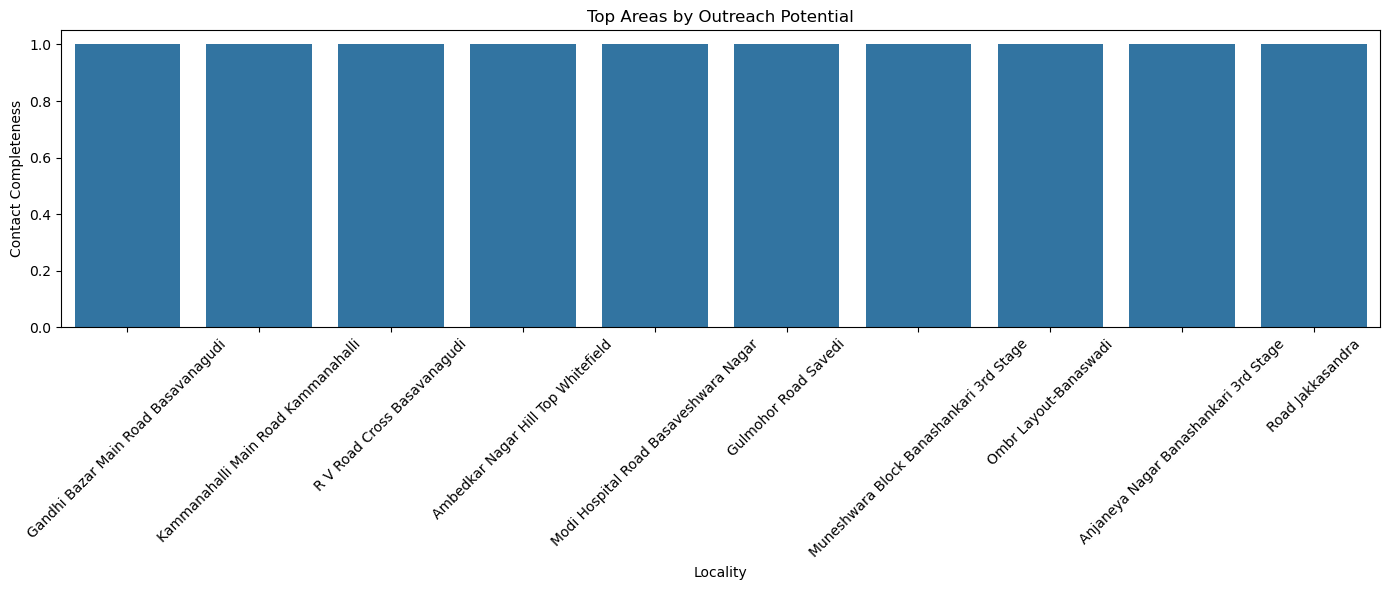

In [35]:
# Outreach Potential


df["has_phone"] = df["phone"].notna()

outreach = (
    df.groupby("area")
    ["has_phone"]
    .mean()
    .reset_index(name="contact_completeness")
    .sort_values(by="contact_completeness", ascending=False)
)

print(outreach.head(10))


# Outreach Chart


plt.figure(figsize=(14,6))

sns.barplot(
    data=outreach.head(10),
    x="area",
    y="contact_completeness"
)

plt.xticks(rotation=45)
plt.title("Top Areas by Outreach Potential")
plt.xlabel("Locality")
plt.ylabel("Contact Completeness")
plt.tight_layout()
plt.show()

In [36]:
output_folder = r"C:\Users\lavan\OneDrive\Desktop\scrapping\output"

locality_counts.to_csv(
    fr"{output_folder}\locality_density_analysis.csv",
    index=False
)

opportunity_df.to_csv(
    fr"{output_folder}\opportunity_gap_analysis.csv",
    index=False
)

category_counts.to_csv(
    fr"{output_folder}\category_analysis.csv",
    index=False
)

quality_hotspots.to_csv(
    fr"{output_folder}\quality_hotspots.csv",
    index=False
)

print("All analysis files exported successfully!")


All analysis files exported successfully!


FINAL BUSINESS RECOMMENDATION

1. Best Area to Launch:
   - Based on opportunity score, demand-supply ratio,
     metro proximity, and lower saturation.

2. Target Segment Fit:
   - Areas near universities and IT parks show
     strongest young professional density.

3. Competitive Landscape:
   - Low inter-centre distance = oversaturated.
   - High inter-centre distance = underserved.

4. Category Opportunity:
   - Categories with highest gap score indicate
     unmet market demand.

5. Outreach Potential:
   - Areas with highest contact completeness
     are best for sales and partnerships.and below are the psudocodes for the same 


import pandas as pd
from geopy.geocoders import Nominatim
import time

from geopy.geocoders import Nominatim
import pandas as pd
import time

geolocator = Nominatim(user_agent="blr_fitness_analysis")

# Function
def get_coordinates(address):
    try:
        location = geolocator.geocode(address)
        if location:
            return pd.Series([location.latitude, location.longitude])
        else:
            return pd.Series([None, None])
    except:
        return pd.Series([None, None])

# Create full address
df["full_address"] = (
    df["area"] + ", Bangalore, Karnataka, India"
)

# Apply geocoding
df[["latitude", "longitude"]] = df["full_address"].apply(get_coordinates)

# Avoid API overload
time.sleep(1)

print(df.head())

import folium
from folium.plugins import HeatMap

blr_map = folium.Map(location=[12.9716, 77.5946], zoom_start=11)

heat_data = df[["latitude", "longitude"]].dropna().values.tolist()

HeatMap(heat_data).add_to(blr_map)

blr_map.save("fitness_density_map.html")

# 4.1.5 Average Inter-Centre Distance

avg_distance_results = []

for locality, group in df.groupby("area"):

    coords = list(zip(group["latitude"], group["longitude"]))

    if len(coords) < 2:
        continue

    distances = []

    for c1, c2 in combinations(coords, 2):
        dist = geodesic(c1, c2).km
        distances.append(dist)

    avg_distance = np.mean(distances)

    avg_distance_results.append({
        "area": locality,
        "avg_intercentre_distance_km": avg_distance
    })

avg_distance_df = pd.DataFrame(avg_distance_results)

avg_distance_df = avg_distance_df.sort_values(
    by="avg_intercentre_distance_km"
)

print(avg_distance_df.head())

# Saturation Chart

plt.figure(figsize=(14,6))

sns.barplot(
    data=avg_distance_df.head(15),
    x="area",
    y="avg_intercentre_distance_km"
)

plt.xticks(rotation=45)
plt.title("Average Inter-Centre Distance by Locality")
plt.xlabel("Locality")
plt.ylabel("Average Distance (km)")
plt.tight_layout()
plt.show()


# Saturation Chart


plt.figure(figsize=(14,6))

sns.barplot(
    data=avg_distance_df.head(15),
    x="area",
    y="avg_intercentre_distance_km"
)

plt.xticks(rotation=45)
plt.title("Average Inter-Centre Distance by Locality")
plt.xlabel("Locality")
plt.ylabel("Average Distance (km)")
plt.tight_layout()
plt.show()


# 4.2 TARGET DEMOGRAPHIC PROXIMITY ANALYSIS

# =============================================

# Example reference points

# Replace with real datasets if available

 
universities = [
    (12.9352, 77.6245),
    (13.0108, 77.5511)
]

it_parks = [
    (12.9350, 77.6950),
    (12.8456, 77.6603)
]

metro_stations = [
    (12.9784, 77.6408),
    (12.9756, 77.6050)
]


# Distance Calculation Function

 
def min_distance(lat, lon, reference_points):

    distances = [
        geodesic((lat, lon), point).km
        for point in reference_points
    ]

    return min(distances)
 

# Compute Proximity Scores
 
df["university_distance"] = df.apply(
    lambda x: min_distance(
        x["latitude"],
        x["longitude"],
        universities
    ),
    axis=1
)


df["itpark_distance"] = df.apply(
    lambda x: min_distance(
        x["latitude"],
        x["longitude"],
        it_parks
    ),
    axis=1
)


df["metro_distance"] = df.apply(
    lambda x: min_distance(
        x["latitude"],
        x["longitude"],
        metro_stations
    ),
    axis=1
)
 
# Composite Opportunity Score

 
scaler = MinMaxScaler()

score_columns = [
    "university_distance",
    "itpark_distance",
    "metro_distance"
]

scaled = scaler.fit_transform(df[score_columns])

scaled_df = pd.DataFrame(
    scaled,
    columns=[
        "uni_scaled",
        "it_scaled",
        "metro_scaled"
    ]
)

# Lower distance = better opportunity

df["opportunity_score"] = (
    (1 - scaled_df["uni_scaled"]) * 0.3 +
    (1 - scaled_df["it_scaled"]) * 0.4 +
    (1 - scaled_df["metro_scaled"]) * 0.3
)
 

# Top Opportunity Localities

 
opportunity_localities = (
    df.groupby("Area / Locality")
    ["opportunity_score"]
    .mean()
    .reset_index()
    .sort_values(by="opportunity_score", ascending=False)
)

print(opportunity_localities.head(10))
 

# Opportunity Score Chart
 
plt.figure(figsize=(14,6))

sns.barplot(
    data=opportunity_localities.head(10),
    x="Area / Locality",
    y="opportunity_score"
)

plt.xticks(rotation=45)
plt.title("Top Opportunity Localities")
plt.xlabel("Locality")
plt.ylabel("Opportunity Score")
plt.tight_layout()
plt.show()
 


 

# =============================================

# 4.5 BUSINESS RECOMMENDATION

# =============================================

# Best Area to Launch


launch_recommendation = pd.merge(
    opportunity_localities,
    locality_counts,
    on="area"
)

launch_recommendation = launch_recommendation.sort_values(
    by=["opportunity_score", "centre_count"],
    ascending=[False, True]
)

print(launch_recommendation.head(10))



# Oversaturated Areas

oversaturated = avg_distance_df.sort_values(
    by="avg_intercentre_distance_km"
)

print(oversaturated.head(10))


# Underserved Areas


underserved = avg_distance_df.sort_values(
    by="avg_intercentre_distance_km",
    ascending=False
)

print(underserved.head(10))


# Category Opportunity Analysis


category_opportunity = (
    underrepresented.groupby("category")
    ["gap_score"]
    .mean()
    .reset_index()
    .sort_values(by="gap_score", ascending=False)
)

print(category_opportunity)